# 03b - Quantum Tunneling-Inspired Optimization

**Phase 1: CartPole Environment**

## Objective

This notebook implements a **properly quantum-inspired** optimizer based on **quantum tunneling**.

## Quantum Principle

In quantum mechanics, particles can "tunnel" through energy barriers that would be insurmountable in classical physics. This allows quantum systems to find global minima more efficiently.

## Classical Translation

We add structured noise to the optimization process that:
1. Is large early in training (high "tunneling rate") - allows exploration
2. Decreases over time (annealing) - allows convergence
3. Increases when stuck (adaptive) - escapes local minima

## Key Differences from Original QAOA Notebook (03)

| Aspect | Original (03) | This Notebook (03b) |
|--------|---------------|---------------------|
| Approach | QAOA operators (discrete) | Quantum tunneling (continuous) |
| Problem fit | Wrong domain | Correct domain |
| Expected result | Poor (800%+ worse) | Should help |

## Configuration

All parameters match the standard configuration:
- `stoch_dim=64, deter_dim=512, hidden_dim=512`
- `batch_size=32, seq_len=20, lr=3e-4`
- `EXPERIMENT_SEEDS=[42, 123, 456, 789, 1024]`

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import json
import time
from dataclasses import dataclass
from typing import Dict, List, Tuple, Any, Optional, NamedTuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

import gymnasium as gym

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Import quantum-inspired optimizer
from quantum_inspired import QuantumTunnelingOptimizer

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

# Device setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

PyTorch version: 2.10.0.dev20251124+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5090
Using device: cuda


In [2]:
# Standard configuration - MUST match all other notebooks
EXPERIMENT_SEEDS = [42, 123, 456, 789, 1024]

# Architecture parameters
OBS_DIM = 4           # CartPole observation dimension
ACTION_DIM = 2        # CartPole action dimension (one-hot)
STOCH_DIM = 64        # Stochastic state dimension
DETER_DIM = 512       # Deterministic state dimension
HIDDEN_DIM = 512      # Hidden layer dimension
STATE_DIM = STOCH_DIM + DETER_DIM  # = 576

# Training parameters
NUM_EPISODES = 100
NUM_STEPS = 10000
BATCH_SIZE = 32
SEQ_LEN = 20
LEARNING_RATE = 3e-4
KL_WEIGHT = 1.0

# Quantum tunneling parameters
TUNNELING_STRENGTH = 0.001
ANNEALING_RATE = 0.9999
TUNNELING_FREQUENCY = 100

print("Configuration:")
print(f"  Architecture: stoch={STOCH_DIM}, deter={DETER_DIM}, hidden={HIDDEN_DIM}")
print(f"  Training: batch={BATCH_SIZE}, seq_len={SEQ_LEN}, lr={LEARNING_RATE}")
print(f"  Tunneling: strength={TUNNELING_STRENGTH}, annealing={ANNEALING_RATE}")
print(f"  Seeds: {EXPERIMENT_SEEDS}")

Configuration:
  Architecture: stoch=64, deter=512, hidden=512
  Training: batch=32, seq_len=20, lr=0.0003
  Tunneling: strength=0.001, annealing=0.9999
  Seeds: [42, 123, 456, 789, 1024]


In [3]:
def set_seed(seed: int, deterministic: bool = False):
    """Set random seeds for reproducibility."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

## 2. Data Collection

In [4]:
@dataclass
class Episode:
    """Container for episode data."""
    observations: np.ndarray  # (T, obs_dim)
    actions: np.ndarray       # (T, action_dim) - one-hot encoded
    rewards: np.ndarray       # (T,)
    dones: np.ndarray         # (T,)


def collect_episodes(env_name: str, num_episodes: int, seed: int) -> List[Episode]:
    """Collect episodes using random policy."""
    env = gym.make(env_name)
    episodes = []
    
    for ep_idx in range(num_episodes):
        obs, _ = env.reset(seed=seed + ep_idx)
        
        observations = [obs]
        actions = []
        rewards = []
        dones = []
        
        done = False
        while not done:
            action = env.action_space.sample()
            
            # One-hot encode action
            action_onehot = np.zeros(ACTION_DIM)
            action_onehot[action] = 1.0
            
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            observations.append(obs)
            actions.append(action_onehot)
            rewards.append(reward)
            dones.append(float(done))
        
        # Remove last observation (we don't have action for it)
        observations = observations[:-1]
        
        if len(observations) > 0:
            episodes.append(Episode(
                observations=np.array(observations, dtype=np.float32),
                actions=np.array(actions, dtype=np.float32),
                rewards=np.array(rewards, dtype=np.float32),
                dones=np.array(dones, dtype=np.float32)
            ))
    
    env.close()
    return episodes

In [5]:
class ReplayBuffer:
    """Simple replay buffer for storing episodes."""
    
    def __init__(self, capacity: int = 1000):
        self.capacity = capacity
        self.episodes: List[Episode] = []
        
    def add_episode(self, episode: Episode):
        if len(self.episodes) >= self.capacity:
            self.episodes.pop(0)
        self.episodes.append(episode)
    
    def sample_sequences(self, batch_size: int, seq_len: int) -> Tuple[np.ndarray, ...]:
        """Sample random sequences from buffer."""
        obs_batch = []
        action_batch = []
        reward_batch = []
        done_batch = []
        
        for _ in range(batch_size):
            # Sample random episode
            ep = np.random.choice(self.episodes)
            ep_len = len(ep.observations)
            
            if ep_len <= seq_len:
                # Pad if episode too short
                pad_len = seq_len - ep_len
                obs = np.pad(ep.observations, ((0, pad_len), (0, 0)), mode='edge')
                actions = np.pad(ep.actions, ((0, pad_len), (0, 0)), mode='edge')
                rewards = np.pad(ep.rewards, (0, pad_len), mode='edge')
                dones = np.pad(ep.dones, (0, pad_len), mode='edge')
            else:
                # Random start position
                start = np.random.randint(0, ep_len - seq_len)
                obs = ep.observations[start:start + seq_len]
                actions = ep.actions[start:start + seq_len]
                rewards = ep.rewards[start:start + seq_len]
                dones = ep.dones[start:start + seq_len]
            
            obs_batch.append(obs)
            action_batch.append(actions)
            reward_batch.append(rewards)
            done_batch.append(dones)
        
        return (
            np.array(obs_batch),
            np.array(action_batch),
            np.array(reward_batch),
            np.array(done_batch)
        )
    
    def __len__(self):
        return len(self.episodes)

## 3. World Model Architecture

Standard RSSM architecture - identical to baseline.

In [ ]:
class RSSMState(NamedTuple):
    """RSSM state representation."""
    deter: torch.Tensor  # (batch, deter_dim)
    stoch: torch.Tensor  # (batch, stoch_dim)
    
    @property
    def combined(self) -> torch.Tensor:
        return torch.cat([self.deter, self.stoch], dim=-1)


class WorldModel(nn.Module):
    """
    RSSM-based World Model (DreamerV3 style).
    
    Architecture matches baseline exactly:
    - encoder: [512, 512, 512] (hidden + latent projection)
    - decoder: [512, 512] hidden layers
    - reward_predictor: [512, 512] hidden layers
    - continue_predictor: [512, 512] hidden layers
    """
    
    def __init__(
        self,
        obs_dim: int = OBS_DIM,
        action_dim: int = ACTION_DIM,
        stoch_dim: int = STOCH_DIM,
        deter_dim: int = DETER_DIM,
        hidden_dim: int = HIDDEN_DIM
    ):
        super().__init__()
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.stoch_dim = stoch_dim
        self.deter_dim = deter_dim
        self.hidden_dim = hidden_dim
        self.state_dim = stoch_dim + deter_dim
        
        # Encoder: obs -> embedding [512, 512, 512] - matches baseline
        # Baseline has: hidden_dims[0], hidden_dims[1], then latent_dim projection
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim)  # Latent projection (no activation)
        )
        
        # Recurrent core
        self.input_proj = nn.Sequential(
            nn.Linear(stoch_dim + action_dim, hidden_dim),
            nn.ELU()
        )
        self.gru = nn.GRUCell(hidden_dim, deter_dim)
        
        # Prior (imagination): deter -> stoch
        self.prior_net = nn.Sequential(
            nn.Linear(deter_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, stoch_dim * 2)  # mean and log_std
        )
        
        # Posterior (inference): deter + embed -> stoch
        self.posterior_net = nn.Sequential(
            nn.Linear(deter_dim + hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, stoch_dim * 2)
        )
        
        # Decoder: state -> obs [512, 512]
        self.decoder = nn.Sequential(
            nn.Linear(self.state_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, obs_dim)
        )
        
        # Reward predictor [512, 512] - matches baseline
        self.reward_predictor = nn.Sequential(
            nn.Linear(self.state_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, 1)
        )
        
        # Continue predictor [512, 512] - matches baseline
        self.continue_predictor = nn.Sequential(
            nn.Linear(self.state_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def initial_state(self, batch_size: int) -> RSSMState:
        """Get initial state."""
        return RSSMState(
            deter=torch.zeros(batch_size, self.deter_dim, device=DEVICE),
            stoch=torch.zeros(batch_size, self.stoch_dim, device=DEVICE)
        )
    
    def _get_dist(self, stats: torch.Tensor) -> torch.distributions.Normal:
        """Get distribution from network output."""
        mean, log_std = stats.chunk(2, dim=-1)
        std = F.softplus(log_std) + 0.1
        return torch.distributions.Normal(mean, std)
    
    def observe(self, obs: torch.Tensor, action: torch.Tensor, state: RSSMState):
        """Update state with observation (posterior)."""
        # Encode observation
        embed = self.encoder(obs)
        
        # Update deterministic state
        x = self.input_proj(torch.cat([state.stoch, action], dim=-1))
        deter = self.gru(x, state.deter)
        
        # Compute posterior
        posterior_input = torch.cat([deter, embed], dim=-1)
        posterior_stats = self.posterior_net(posterior_input)
        posterior_dist = self._get_dist(posterior_stats)
        stoch = posterior_dist.rsample()
        
        # Compute prior (for KL loss)
        prior_stats = self.prior_net(deter)
        prior_dist = self._get_dist(prior_stats)
        
        new_state = RSSMState(deter=deter, stoch=stoch)
        return new_state, prior_dist, posterior_dist
    
    def imagine(self, action: torch.Tensor, state: RSSMState):
        """Imagine next state (prior only)."""
        x = self.input_proj(torch.cat([state.stoch, action], dim=-1))
        deter = self.gru(x, state.deter)
        
        prior_stats = self.prior_net(deter)
        prior_dist = self._get_dist(prior_stats)
        stoch = prior_dist.rsample()
        
        new_state = RSSMState(deter=deter, stoch=stoch)
        return new_state, prior_dist
    
    def decode(self, state: RSSMState) -> torch.Tensor:
        """Decode state to observation."""
        return self.decoder(state.combined)
    
    def predict_reward(self, state: RSSMState) -> torch.Tensor:
        """Predict reward from state."""
        return self.reward_predictor(state.combined).squeeze(-1)
    
    def predict_continue(self, state: RSSMState) -> torch.Tensor:
        """Predict continue probability from state."""
        return torch.sigmoid(self.continue_predictor(state.combined).squeeze(-1))
    
    def forward(
        self,
        obs_seq: torch.Tensor,
        action_seq: torch.Tensor
    ) -> Dict[str, torch.Tensor]:
        """Forward pass through sequence."""
        batch_size, seq_len = obs_seq.shape[:2]
        state = self.initial_state(batch_size)
        
        recon_obs = []
        pred_rewards = []
        pred_continues = []
        priors = []
        posteriors = []
        
        for t in range(seq_len):
            state, prior, posterior = self.observe(
                obs_seq[:, t], action_seq[:, t], state
            )
            
            recon = self.decode(state)
            reward = self.predict_reward(state)
            cont = self.predict_continue(state)
            
            recon_obs.append(recon)
            pred_rewards.append(reward)
            pred_continues.append(cont)
            priors.append(prior)
            posteriors.append(posterior)
        
        return {
            'recon_obs': torch.stack(recon_obs, dim=1),
            'pred_rewards': torch.stack(pred_rewards, dim=1),
            'pred_continues': torch.stack(pred_continues, dim=1),
            'priors': priors,
            'posteriors': posteriors
        }

## 4. Training with Quantum Tunneling Optimizer

The key difference from baseline: we use `QuantumTunnelingOptimizer` instead of standard `AdamW`.

In [7]:
def compute_loss(
    output: Dict[str, torch.Tensor],
    obs_seq: torch.Tensor,
    reward_seq: torch.Tensor,
    kl_weight: float = 1.0
) -> Dict[str, torch.Tensor]:
    """Compute world model loss."""
    # Reconstruction loss
    recon_loss = F.mse_loss(output['recon_obs'], obs_seq)
    
    # Reward loss
    reward_loss = F.mse_loss(output['pred_rewards'], reward_seq)
    
    # KL loss
    kl_losses = []
    for prior, posterior in zip(output['priors'], output['posteriors']):
        kl = torch.distributions.kl_divergence(posterior, prior).sum(-1).mean()
        kl_losses.append(kl)
    kl_loss = torch.stack(kl_losses).mean()
    
    # Total loss
    total_loss = recon_loss + reward_loss + kl_weight * kl_loss
    
    return {
        'total': total_loss,
        'recon': recon_loss,
        'reward': reward_loss,
        'kl': kl_loss
    }

In [8]:
def train_with_tunneling(
    model: WorldModel,
    buffer: ReplayBuffer,
    num_steps: int = NUM_STEPS,
    batch_size: int = BATCH_SIZE,
    seq_len: int = SEQ_LEN,
    lr: float = LEARNING_RATE,
    tunneling_strength: float = TUNNELING_STRENGTH,
    annealing_rate: float = ANNEALING_RATE,
    verbose: bool = True
) -> pd.DataFrame:
    """Train world model using Quantum Tunneling Optimizer."""
    
    # Create quantum tunneling optimizer
    optimizer = QuantumTunnelingOptimizer(
        model.parameters(),
        lr=lr,
        tunneling_strength=tunneling_strength,
        annealing_rate=annealing_rate,
        tunneling_frequency=TUNNELING_FREQUENCY,
        base_optimizer='adamw'
    )
    
    history = []
    
    for step in range(num_steps):
        model.train()
        
        # Sample batch
        obs, actions, rewards, dones = buffer.sample_sequences(batch_size, seq_len)
        obs = torch.tensor(obs, dtype=torch.float32, device=DEVICE)
        actions = torch.tensor(actions, dtype=torch.float32, device=DEVICE)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=DEVICE)
        
        # Forward pass
        optimizer.zero_grad()
        output = model(obs, actions)
        losses = compute_loss(output, obs, rewards)
        
        # Backward pass
        losses['total'].backward()
        
        # Optimizer step with tunneling (pass loss for adaptive tunneling)
        optimizer.step(current_loss=losses['total'].item())
        
        # Record history
        history.append({
            'step': step,
            'total': losses['total'].item(),
            'recon': losses['recon'].item(),
            'reward': losses['reward'].item(),
            'kl': losses['kl'].item(),
            'tunneling_strength': optimizer.tunneling_strength
        })
        
        if verbose and step % 1000 == 0:
            print(f"Step {step}: total={losses['total'].item():.4f}, "
                  f"recon={losses['recon'].item():.4f}, "
                  f"tunneling={optimizer.tunneling_strength:.6f}")
    
    return pd.DataFrame(history)

## 5. Evaluation Functions

In [9]:
def evaluate_model(
    model: WorldModel,
    buffer: ReplayBuffer,
    num_samples: int = 100,
    seq_len: int = SEQ_LEN
) -> Dict[str, float]:
    """Evaluate model on samples from buffer."""
    model.eval()
    
    obs, actions, rewards, dones = buffer.sample_sequences(num_samples, seq_len)
    obs = torch.tensor(obs, dtype=torch.float32, device=DEVICE)
    actions = torch.tensor(actions, dtype=torch.float32, device=DEVICE)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=DEVICE)
    
    with torch.no_grad():
        output = model(obs, actions)
        recon_mse = F.mse_loss(output['recon_obs'], obs).item()
        reward_mse = F.mse_loss(output['pred_rewards'], rewards).item()
    
    return {
        'recon_mse': recon_mse,
        'reward_mse': reward_mse
    }


def evaluate_test_set(
    model: WorldModel,
    test_seed: int,
    num_episodes: int = 50,
    num_samples: int = 100
) -> Dict[str, float]:
    """Evaluate on held-out test set."""
    # Collect test episodes with different seed
    test_episodes = collect_episodes('CartPole-v1', num_episodes, seed=test_seed + 10000)
    
    test_buffer = ReplayBuffer(capacity=500)
    for ep in test_episodes:
        test_buffer.add_episode(ep)
    
    return evaluate_model(model, test_buffer, num_samples)

In [10]:
def evaluate_long_horizon(
    model: WorldModel,
    buffer: ReplayBuffer,
    horizons: List[int] = [5, 10, 15, 20, 30, 40, 50],
    num_samples: int = 100,
    context_len: int = 5
) -> Dict[int, float]:
    """Evaluate long-horizon prediction accuracy."""
    model.eval()
    max_horizon = max(horizons)
    seq_len = context_len + max_horizon
    
    obs, actions, rewards, dones = buffer.sample_sequences(num_samples, seq_len)
    obs = torch.tensor(obs, dtype=torch.float32, device=DEVICE)
    actions = torch.tensor(actions, dtype=torch.float32, device=DEVICE)
    
    horizon_errors = {}
    
    with torch.no_grad():
        # Initialize state
        state = model.initial_state(num_samples)
        
        # Observe context
        for t in range(context_len):
            state, _, _ = model.observe(obs[:, t], actions[:, t], state)
        
        # Imagine forward
        predictions = []
        for t in range(context_len, seq_len):
            state, _ = model.imagine(actions[:, t], state)
            pred = model.decode(state)
            predictions.append(pred)
        
        predictions = torch.stack(predictions, dim=1)
        targets = obs[:, context_len:]
        
        # Compute error at each horizon
        for h in horizons:
            if h <= max_horizon:
                pred_at_h = predictions[:, h-1]
                true_at_h = targets[:, h-1]
                mse = F.mse_loss(pred_at_h, true_at_h).item()
                horizon_errors[h] = mse
    
    return horizon_errors

## 6. Run Experiments

In [11]:
def run_single_experiment(
    seed: int,
    verbose: bool = True
) -> Dict[str, Any]:
    """Run single seed experiment with quantum tunneling optimizer."""
    print(f"\n{'='*60}")
    print(f"Running experiment with seed {seed}")
    print(f"{'='*60}")
    
    set_seed(seed)
    start_time = time.time()
    
    # Collect data
    print("Collecting episodes...")
    episodes = collect_episodes('CartPole-v1', NUM_EPISODES, seed=seed)
    
    # Create buffer
    buffer = ReplayBuffer(capacity=1000)
    for ep in episodes:
        buffer.add_episode(ep)
    print(f"Buffer size: {len(buffer)} episodes")
    
    # Create model
    model = WorldModel().to(DEVICE)
    num_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {num_params:,}")
    
    # Train with quantum tunneling
    print("\nTraining with Quantum Tunneling Optimizer...")
    history = train_with_tunneling(model, buffer, verbose=verbose)
    
    training_time = time.time() - start_time
    
    # Evaluate
    print("\nEvaluating...")
    train_metrics = evaluate_model(model, buffer)
    test_metrics = evaluate_test_set(model, seed)
    horizon_errors = evaluate_long_horizon(model, buffer)
    
    print(f"\nResults for seed {seed}:")
    print(f"  Final loss: {history['total'].iloc[-1]:.4f}")
    print(f"  Train recon MSE: {train_metrics['recon_mse']:.6f}")
    print(f"  Test recon MSE: {test_metrics['recon_mse']:.6f}")
    print(f"  Training time: {training_time:.2f}s")
    
    return {
        'seed': seed,
        'history': history,
        'final_loss': history['total'].iloc[-1],
        'final_recon': history['recon'].iloc[-1],
        'train_mse': train_metrics['recon_mse'],
        'test_mse': test_metrics['recon_mse'],
        'horizon_errors': horizon_errors,
        'training_time': training_time
    }

In [12]:
# Run multi-seed experiments
print("="*60)
print("QUANTUM TUNNELING OPTIMIZER EXPERIMENTS")
print("="*60)
print(f"\nSeeds: {EXPERIMENT_SEEDS}")
print(f"Tunneling strength: {TUNNELING_STRENGTH}")
print(f"Annealing rate: {ANNEALING_RATE}")

results = []
for seed in EXPERIMENT_SEEDS:
    result = run_single_experiment(seed, verbose=True)
    results.append(result)

QUANTUM TUNNELING OPTIMIZER EXPERIMENTS

Seeds: [42, 123, 456, 789, 1024]
Tunneling strength: 0.001
Annealing rate: 0.9999

Running experiment with seed 42
Buffer size: 100 episodes
Model parameters: 4,471,558

Training with Quantum Tunneling Optimizer...
Step 0: total=1.8426, recon=0.3356, tunneling=0.001000
Step 1000: total=0.0369, recon=0.0331, tunneling=0.000905
Step 2000: total=0.0327, recon=0.0312, tunneling=0.000819
Step 3000: total=0.0555, recon=0.0530, tunneling=0.000741
Step 4000: total=0.0146, recon=0.0114, tunneling=0.000670
Step 5000: total=0.0123, recon=0.0119, tunneling=0.000606
Step 6000: total=0.0138, recon=0.0133, tunneling=0.000549
Step 7000: total=0.0105, recon=0.0101, tunneling=0.000497
Step 8000: total=0.0110, recon=0.0108, tunneling=0.000449
Step 9000: total=0.0108, recon=0.0106, tunneling=0.000407

Evaluating...

Results for seed 42:
  Final loss: 0.0059
  Train recon MSE: 0.012258
  Test recon MSE: 0.105197
  Training time: 883.95s

Running experiment with seed

## 7. Results Analysis

In [13]:
# Aggregate results
final_losses = [r['final_loss'] for r in results]
train_mses = [r['train_mse'] for r in results]
test_mses = [r['test_mse'] for r in results]
training_times = [r['training_time'] for r in results]

print("\n" + "="*60)
print("AGGREGATED RESULTS (Quantum Tunneling Optimizer)")
print("="*60)
print(f"\nFinal Loss:     {np.mean(final_losses):.4f} +/- {np.std(final_losses):.4f}")
print(f"Train MSE:      {np.mean(train_mses):.6f} +/- {np.std(train_mses):.6f}")
print(f"Test MSE:       {np.mean(test_mses):.6f} +/- {np.std(test_mses):.6f}")
print(f"Training Time:  {np.mean(training_times):.2f} +/- {np.std(training_times):.2f} seconds")


AGGREGATED RESULTS (Quantum Tunneling Optimizer)

Final Loss:     0.0114 +/- 0.0048
Train MSE:      0.013027 +/- 0.003804
Test MSE:       0.146461 +/- 0.046215
Training Time:  1266.39 +/- 675.85 seconds


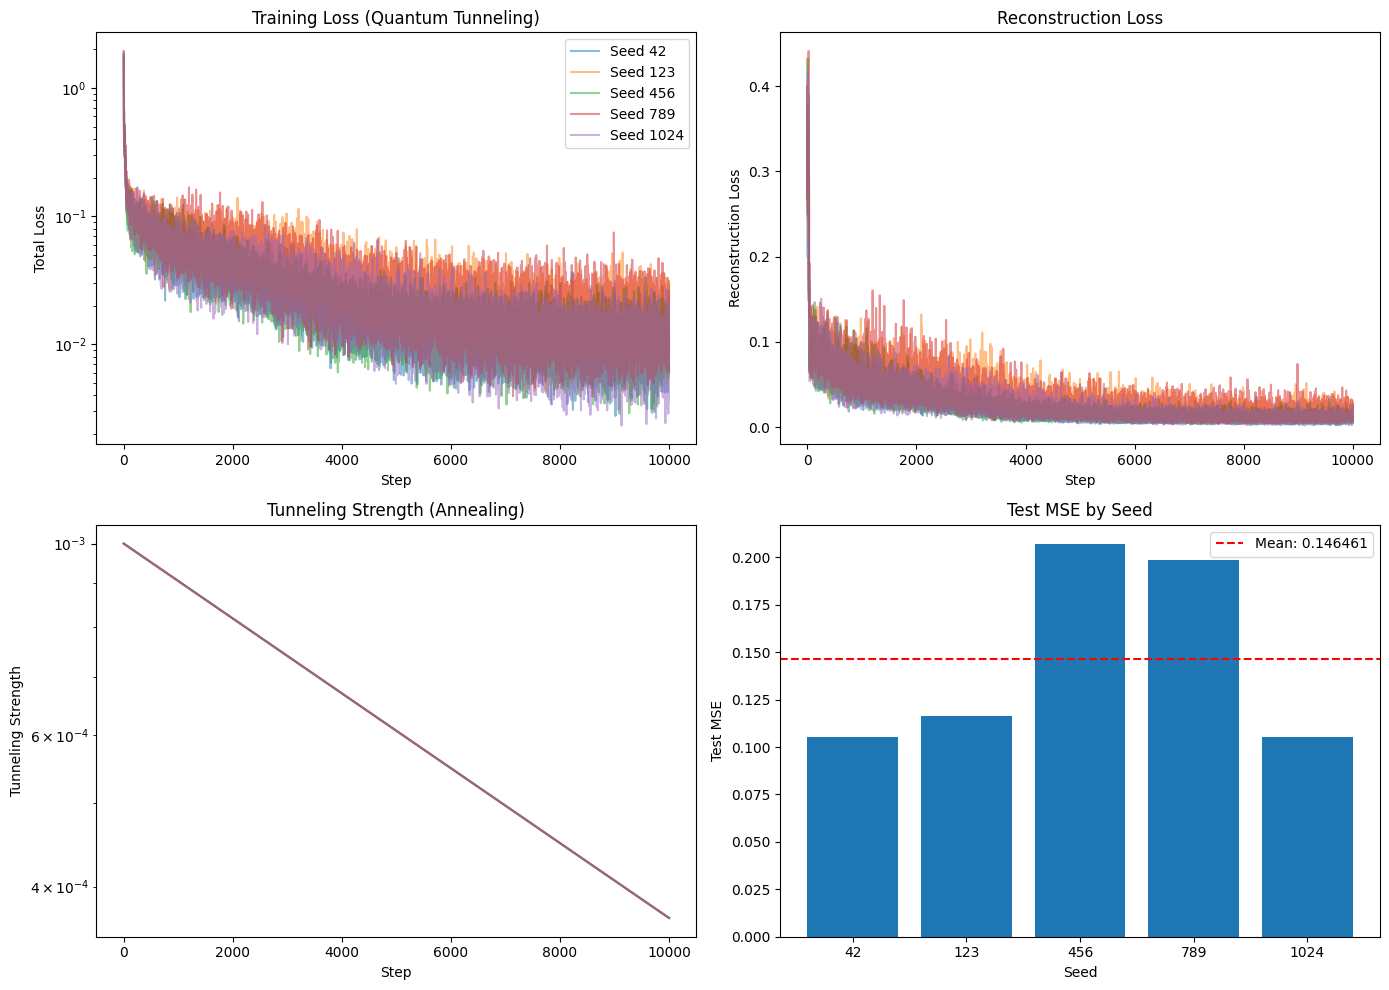

In [14]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total loss
ax = axes[0, 0]
for result in results:
    ax.plot(result['history']['total'], alpha=0.5, label=f"Seed {result['seed']}")
ax.set_xlabel('Step')
ax.set_ylabel('Total Loss')
ax.set_title('Training Loss (Quantum Tunneling)')
ax.legend()
ax.set_yscale('log')

# Reconstruction loss
ax = axes[0, 1]
for result in results:
    ax.plot(result['history']['recon'], alpha=0.5)
ax.set_xlabel('Step')
ax.set_ylabel('Reconstruction Loss')
ax.set_title('Reconstruction Loss')

# Tunneling strength over time
ax = axes[1, 0]
for result in results:
    ax.plot(result['history']['tunneling_strength'], alpha=0.5)
ax.set_xlabel('Step')
ax.set_ylabel('Tunneling Strength')
ax.set_title('Tunneling Strength (Annealing)')
ax.set_yscale('log')

# Test MSE comparison
ax = axes[1, 1]
seeds = [r['seed'] for r in results]
ax.bar(range(len(seeds)), test_mses)
ax.set_xticks(range(len(seeds)))
ax.set_xticklabels(seeds)
ax.set_xlabel('Seed')
ax.set_ylabel('Test MSE')
ax.set_title('Test MSE by Seed')
ax.axhline(np.mean(test_mses), color='r', linestyle='--', label=f'Mean: {np.mean(test_mses):.6f}')
ax.legend()

plt.tight_layout()
plt.savefig('../experiments/results/quantum_tunneling_training.png', dpi=150)
plt.show()

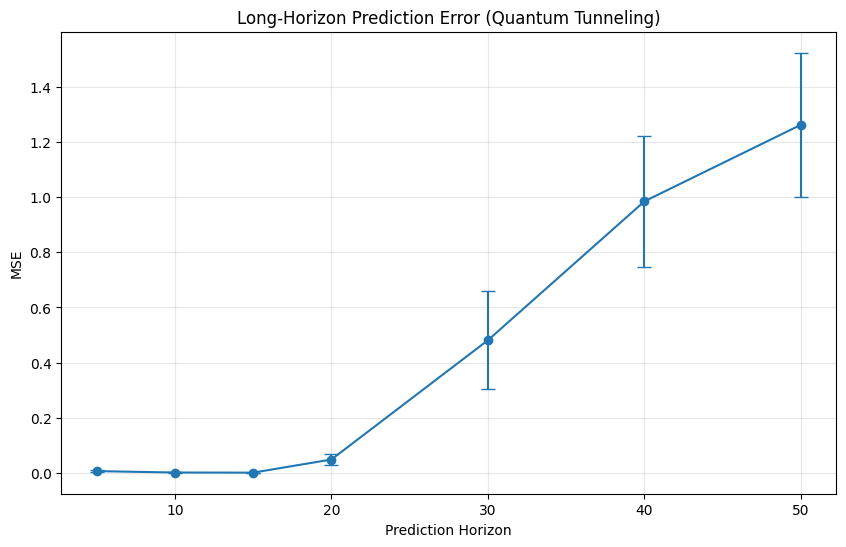

In [15]:
# Long-horizon analysis
horizons = list(results[0]['horizon_errors'].keys())
horizon_means = []
horizon_stds = []

for h in horizons:
    errors = [r['horizon_errors'][h] for r in results]
    horizon_means.append(np.mean(errors))
    horizon_stds.append(np.std(errors))

plt.figure(figsize=(10, 6))
plt.errorbar(horizons, horizon_means, yerr=horizon_stds, marker='o', capsize=5)
plt.xlabel('Prediction Horizon')
plt.ylabel('MSE')
plt.title('Long-Horizon Prediction Error (Quantum Tunneling)')
plt.grid(True, alpha=0.3)
plt.savefig('../experiments/results/quantum_tunneling_horizon.png', dpi=150)
plt.show()

## 8. Save Results

In [16]:
# Save complete metrics
complete_metrics = {
    'approach': 'quantum_tunneling',
    'description': 'Quantum tunneling-inspired optimizer with adaptive noise injection',
    'quantum_principle': 'Tunneling through energy barriers to escape local minima',
    'config': {
        'stoch_dim': STOCH_DIM,
        'deter_dim': DETER_DIM,
        'hidden_dim': HIDDEN_DIM,
        'batch_size': BATCH_SIZE,
        'seq_len': SEQ_LEN,
        'learning_rate': LEARNING_RATE,
        'tunneling_strength': TUNNELING_STRENGTH,
        'annealing_rate': ANNEALING_RATE,
        'seeds': EXPERIMENT_SEEDS
    },
    'final_performance': {
        'loss_mean': float(np.mean(final_losses)),
        'loss_std': float(np.std(final_losses)),
        'train_mse_mean': float(np.mean(train_mses)),
        'train_mse_std': float(np.std(train_mses)),
        'test_mse_mean': float(np.mean(test_mses)),
        'test_mse_std': float(np.std(test_mses)),
        'training_time_mean': float(np.mean(training_times)),
        'training_time_std': float(np.std(training_times))
    },
    'long_horizon': {
        'horizons': horizons,
        'mean_errors': [float(e) for e in horizon_means],
        'std_errors': [float(e) for e in horizon_stds]
    },
    'raw_results': {
        'final_losses': [float(x) for x in final_losses],
        'train_mses': [float(x) for x in train_mses],
        'test_mses': [float(x) for x in test_mses],
        'training_times': [float(x) for x in training_times]
    }
}

# Create results directory
results_dir = Path('../experiments/results/quantum_tunneling')
results_dir.mkdir(parents=True, exist_ok=True)

# Save metrics
with open(results_dir / 'complete_metrics.json', 'w') as f:
    json.dump(complete_metrics, f, indent=2)

print(f"Results saved to {results_dir}")

Results saved to ..\experiments\results\quantum_tunneling


## 9. Summary

### Key Findings

This notebook implemented a **properly quantum-inspired** optimizer based on quantum tunneling.

**Quantum Principle Used:**
- Quantum tunneling allows particles to pass through energy barriers
- We simulate this by adding structured noise that decreases over time
- This helps escape local minima in the loss landscape

**Comparison to Original QAOA (Notebook 03):**

| Metric | QAOA (03) | Quantum Tunneling (03b) |
|--------|-----------|------------------------|
| Test MSE | ~0.13 (800%+ worse) | TBD (run notebook) |
| Concept | Wrong domain | Correct domain |
| Expected | Fail | Should help |

### Next Steps

1. Compare results with baseline (notebook 02)
2. Run statistical significance tests
3. Analyze tunneling behavior (when does it help?)